<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/ShortestPath-5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports

In [1]:
import pandas as pd
import json
import os
import glob

Set the Path to the Data location (imported form SharpHound)

# Set the Path
to the Data location (imported from SharpHound) and Read json files in folder and create a dictionary with the entire data.





In [2]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

!mkdir = "/content/adsync"
!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync

path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-07-27 10:20:53--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1314149 (1.3M) [text/plain]
Saving to: ‘secure.json’

secure.json         100%[===================>]   1.25M  --.-KB/s    in 0.06s   

2025-07-27 10:20:54 (20.1 MB/s) - ‘secure.json’ saved [1314149/1314149]



Show the "content"

In [3]:
#content


In [3]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges

import pandas as pd
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [5]:
# prompt: what is the length of nodes['id] for the last record


In [4]:
nodes.tail()

#print(len(nodes["id"].iloc[-1]))

,id,labels,properties,type,start,end,label
1292,1292,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,NaN,NaN,NaN
1293,1293,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,NaN,NaN,NaN
1294,1294,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,NaN,NaN,NaN
1295,1295,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,NaN,NaN,NaN
1296,1296,"[Base, Group]","{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,NaN,NaN,NaN


In [7]:
# prompt: show all rows


pd.set_option('display.max_rows', None)



In [5]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))


In [6]:
# prompt: remove the following columns from nodes:
# start, end, label

nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])


In [7]:

edges = edges.drop(columns=['labels'])


Expand "Properties" column in new columns.

Convert to Dict

In [11]:
pd.set_option("display.max_rows", None, "display.max_columns", None)

#nodes

In [8]:
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')


In [13]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# nodes_json = nodes.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('nodes.json', 'w') as f:
#   f.write(nodes_json)


In [14]:
# prompt: save the df_compuers as json to content

# import json

# # Assuming df_computers is already defined as in your provided code.

# # Convert the DataFrame to a JSON string.
# edges_json = edges.to_json(orient='records')

# # Save the JSON string to a file named 'content.json'.
# with open('edges.json', 'w') as f:
#   f.write(edges_json)

In [9]:
# prompt: create a new column in nodes called weight

nodes['weight'] = 1

In [16]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

nodes.tail()

,id,properties,type,l1,l2,l3,weight
1292,1292,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder45_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2009', 'distinguishedname': 'CN=T2_HR_FOLDER45_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1


In [13]:
# 1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()


tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    )
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']
        )
    )
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))

tier 0  43
tier 1  58
tier 2  949


In [18]:
type(tier0_node_ids)

list

In [14]:
# prompt: find records from nodes where distinguishedname has "CN=Enterprise Admins," or  distinguishedname has "CN=Domain Admins,"  then append id to tier0_node_ids if not already present

# Assuming 'nodes' DataFrame is already defined from the preceding code

# Initialize an empty list to store the IDs
#tier0_node_ids = []

# Iterate through each row of the 'nodes' DataFrame
for index, row in nodes.iterrows():
    properties = row['properties']
    node_id = row['id']

    # Check if 'properties' is a dictionary and contains 'distinguishedname'
    if isinstance(properties, dict) and 'distinguishedname' in properties:
        distinguishedname = properties['distinguishedname']

        # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
        if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname:
            # Append the id if it's not already in the list
            if node_id not in tier0_node_ids:
                tier0_node_ids.append(node_id)

print(f"tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): {len(tier0_node_ids)}")
# The existing prints for tier1 and tier2 will remain the same
print(f"tier 1 : {len(tier1_node_ids)}")
print(f"tier 2 : {len(tier2_node_ids)}")
print("Tier 0 Node IDs:", tier0_node_ids)

tier 0 (including 'CN=Enterprise Admins,' or 'CN=Domain Admins,'): 45
tier 1 : 58
tier 2 : 949
Tier 0 Node IDs: [4, 7, 8, 9, 10, 295, 296, 301, 303, 305, 306, 307, 318, 324, 331, 341, 357, 392, 405, 444, 448, 457, 458, 467, 469, 481, 527, 530, 531, 532, 553, 607, 610, 625, 631, 632, 640, 645, 653, 663, 686, 692, 9999, 65, 66]


In [15]:
# prompt: show me the last 5 entries in tier0_node_ids

print(tier0_node_ids[-5:])

[686, 692, 9999, 65, 66]


In [21]:
# prompt: find records from nodes where 'admincount' = True and 'highvalue' = True and  (distinguishedname has "T0" or "Tier 0" or "TIER 0")

# Filter nodes based on conditions
# filtered_node = nodes[
#     nodes['properties'].apply(
#         lambda x: x.get('admincount', False) == "True" and
#                   x.get('highvalue', False) == "True" and
#                   any(term in x.get('distinguishedname', '') for term in ["T0", "Tier 0", "TIER 0"])
#     )
# ]

# # Display the filtered nodes
# print("Records where 'admincount' and 'highvalue' are True, and distinguishedname contains 'T0', 'Tier 0', or 'TIER 0':")

# filtered_node

In [22]:
len(tier0_node_ids)

44

In [16]:
# prompt: find records from nodes where "objectid" ends with match(r'.*-\d{3}$' and highvalue=true and admincount=true.

import re

# Filter nodes where 'objectid' ends with a dash followed by exactly three digits,
# 'highvalue' is True, and 'admincount' is True.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-\d{3}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

# Display the filtered nodes
print("Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:")
filtered_nodes

Records where 'objectid' ends with - followed by three digits, and 'highvalue' and 'admincount' are True:


,id,properties,type,l1,l2,l3,weight
36,36,"{'domain': 'MARK.LOCAL', 'name': 'ADMINISTRATO...",node,Base,Group,None,1
38,38,"{'domain': 'MARK.LOCAL', 'name': 'PRINT OPERAT...",node,Base,Group,None,1
40,40,"{'domain': 'MARK.LOCAL', 'name': 'BACKUP OPERA...",node,Base,Group,None,1
59,59,"{'domain': 'MARK.LOCAL', 'name': 'SERVER OPERA...",node,Base,Group,None,1
60,60,"{'domain': 'MARK.LOCAL', 'name': 'ACCOUNT OPER...",node,Base,Group,None,1
65,65,"{'domain': 'MARK.LOCAL', 'name': 'ENTERPRISE A...",node,Base,Group,None,1
66,66,"{'domain': 'MARK.LOCAL', 'name': 'DOMAIN ADMIN...",node,Base,Group,None,1
72,72,"{'domain': 'MARK.LOCAL', 'name': 'DOMAIN CONTR...",node,Base,Group,None,1


In [17]:
# prompt:  check if "id" from filtered_nodes is in tier0_node_ids, if not then append to tier0_node_ids

# Assuming filtered_nodes DataFrame is already defined from the preceding code

# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")
print("Updated Tier 0 Node IDs:", tier0_node_ids)


tier 0 (after checking filtered_nodes): 51
Updated Tier 0 Node IDs: [4, 7, 8, 9, 10, 295, 296, 301, 303, 305, 306, 307, 318, 324, 331, 341, 357, 392, 405, 444, 448, 457, 458, 467, 469, 481, 527, 530, 531, 532, 553, 607, 610, 625, 631, 632, 640, 645, 653, 663, 686, 692, 9999, 65, 66, 36, 38, 40, 59, 60, 72]


In [18]:
# prompt: CHANGE THE VALUES OF tier0_node_ids TO INT64

import numpy as np
tier0_node_ids = np.array(tier0_node_ids, dtype=np.int64)
print("Data type of tier0_node_ids:", tier0_node_ids.dtype)

Data type of tier0_node_ids: int64


In [19]:
# prompt: sort tier0_node_ids ascending

import numpy as np
tier0_node_ids = np.sort(tier0_node_ids)

# print("Sorted Tier 0 Node IDs:", tier0_node_ids)
# print("Data type of tier0_node_ids after sorting:", tier0_node_ids.dtype)
# print(f"tier 0 count (after sorting): {len(tier0_node_ids)}")
# print(tier0_node_ids[-5:])

In [86]:
tier0_node_ids

array([   4,    7,    8,    9,   10,   36,   38,   40,   59,   60,   65,
         66,   72,  295,  296,  301,  303,  305,  306,  307,  318,  324,
        331,  341,  357,  392,  405,  444,  448,  457,  458,  467,  469,
        481,  527,  530,  531,  532,  553,  607,  610,  625,  631,  632,
        640,  645,  653,  663,  686,  692, 9999])

In [20]:
filtered_nodes.dtypes

,0
id,int64
properties,object
type,object
l1,object
l2,object
l3,object
weight,int64


In [21]:
nodes.keys()


Index(['id', 'properties', 'type', 'l1', 'l2', 'l3', 'weight'], dtype='object')

In [29]:
len(tier0_node_ids)

50

In [22]:
len(nodes)

1298

In [23]:
nodes.tail()

,id,properties,type,l1,l2,l3,weight
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@T...",node,ALL_T0,ALL_T0,ALL_T0,100


In [28]:

for value in tier0_node_ids:
    if value  == 9999:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5

nodes.head()

,id,properties,type,l1,l2,l3,weight
0,0,"{'domain': 'MARK.LOCAL', 'name': 'MARK.LOCAL',...",node,Base,Domain,None,1
1,1,"{'domain': 'MARK.LOCAL', 'name': 'Admin@MARK.L...",node,Base,OU,None,1
2,2,"{'domain': 'MARK.LOCAL', 'name': 'Tier 1 Serve...",node,Base,OU,None,10
3,3,"{'domain': 'MARK.LOCAL', 'name': 'Tier 2@MARK....",node,Base,OU,None,5
4,4,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin@MAR...",node,Base,OU,None,20


In [33]:
# prompt: get a unique list of label from edges and save it to list called edges_labels

edges_labels = edges['label'].unique().tolist()
edges_labels

['Contains',
 'GpLink',
 'GenericAll',
 'MemberOf',
 'GenericWrite',
 'WriteDacl',
 'Owns',
 'WriteOwner',
 'GetChanges',
 'GetChangesAll',
 'AllExtendedRights',
 'AdminTo',
 'HasSession',
 'ReadLAPSPassword',
 'CanRDP',
 'ExecuteDCOM',
 'AddSelf',
 'ForceChangePassword',
 'AddMember']

In [11]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 9999


In [12]:
 #prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
display(nodes.tail())

Nodes DataFrame after adding the new record:


,id,properties,type,l1,l2,l3,weight
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,1
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@T...",node,ALL_T0,ALL_T0,ALL_T0,100


In [32]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'start': tier0_id,
        'end': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
display(edges.tail())

Edges DataFrame after adding new TIER0 edges:


,id,properties,type,start,end,label,weight
4020,4020,NaN,relationship,653,9999,TIER0,100.0
4021,4021,NaN,relationship,663,9999,TIER0,100.0
4022,4022,NaN,relationship,686,9999,TIER0,100.0
4023,4023,NaN,relationship,692,9999,TIER0,100.0
4024,4024,NaN,relationship,9999,9999,TIER0,100.0


In [33]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head(50)
#clear_output()


Edges_all DataFrame with weight column:


In [34]:
# prompt: from edges['start'] get 'id' and from edges['end] get 'id'
# replace start with edges['start'][id'] and  end with edges['end']['id']

edges['start'] = edges['start'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
edges['end'] = edges['end'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)

In [35]:
len(edges)

4025

In [38]:
print("\nEdges_all DataFrame with weight column:")
edges.tail(60)


Edges_all DataFrame with weight column:


,id,properties,type,start,end,label,weight
3965,3965,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,66,18,GenericAll,9
3966,3966,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,66,24,GenericAll,9
3967,3967,"{'isacl': True, 'isInherited': True, 'inherita...",relationship,65,101,GenericAll,9
3968,3968,"{'isacl': True, 'isInherited': True, 'inherita...",relationship,65,1,GenericAll,9
3969,3969,"{'isacl': True, 'isInherited': True, 'inherita...",relationship,65,3,GenericAll,9
3970,3970,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,66,1,GenericAll,9
3971,3971,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,66,3,GenericAll,9
3972,3972,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,60,101,GenericAll,9
3973,3973,"{'isacl': True, 'isInherited': False, 'inherit...",relationship,66,101,GenericAll,9
3974,3974,NaN,relationship,4,9999,TIER0,100


In [39]:

edges = edges.drop(columns=['properties']) #, 'id'])

In [40]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')
edges.head()
edges['id'].dtype

dtype('int64')

In [ ]:
# prompt: create a unique id for each row, make sure it is of type int64

import numpy as np
edges['id'] = np.arange(len(edges)).astype('int64')

In [43]:

edges.keys()

Index(['id', 'type', 'start', 'end', 'label', 'weight'], dtype='object')

In [41]:
edges.tail()

,id,type,start,end,label,weight
4020,4020,relationship,653,9999,TIER0,100
4021,4021,relationship,663,9999,TIER0,100
4022,4022,relationship,686,9999,TIER0,100
4023,4023,relationship,692,9999,TIER0,100
4024,4024,relationship,9999,9999,TIER0,100


In [45]:
edges.tail()

,id,type,start,end,label,weight
4019,4019,relationship,645,9999,TIER0,100
4020,4020,relationship,653,9999,TIER0,100
4021,4021,relationship,663,9999,TIER0,100
4022,4022,relationship,686,9999,TIER0,100
4023,4023,relationship,692,9999,TIER0,100


In [42]:
# prompt: make edges['start'] and edges['end'] int64

edges['start'] = edges['start'].astype('int64')
edges['end'] = edges['end'].astype('int64')

In [43]:
# prompt: filter where edges['id'] = tier2_node_ids and call the dataframe selected_ddges

selected_edges = edges[edges['end'].isin(tier0_node_ids)]
len(selected_edges)

289

In [44]:
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4025 entries, 0 to 4024
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      4025 non-null   int64 
 1   type    4025 non-null   object
 2   start   4025 non-null   int64 
 3   end     4025 non-null   int64 
 4   label   4025 non-null   object
 5   weight  4025 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 188.8+ KB


In [45]:
# prompt: selected_edges_t0 = edges[edges['end'].isin(tier0_node_ids)] and selected_edges_t0=edges[edges'start'] is not in tier0_node_ids

selected_edges_t0 = edges[
    (edges['end'].isin(tier0_node_ids))
#    & (~edges['start'].isin(tier0_node_ids))
]
len(selected_edges_t0)

289

In [ ]:
selected_edges_t1 = edges[edges['start'].isin(tier1_node_ids)]
#selected_edges_t1
selected_edges_t2 = edges[edges['start'].isin(tier2_node_ids)]
#selected_edges_t2

In [47]:
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]

In [48]:
len(selected_nodes)

949

In [49]:
nodes.tail()

,id,properties,type,l1,l2,l3,weight
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,5
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,5
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,5
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder...",node,Base,Group,None,5
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@T...",node,ALL_T0,ALL_T0,ALL_T0,100


In [53]:
len(edges)

4024

In [50]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['start'], row['end'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier0_node_ids
    }
    for source, paths in shortest_paths.items()
}

# Print the shortest paths (optional)
for source, paths in shortest_paths_filtered.items():
  if paths:
    #print(f"Shortest paths from node {source}:")
    for target, path in paths.items():
        #print(f"  To node {target}: {path}")
        ShortestPath = source, target, path
       # print(ShortestPath)

In [51]:
shortest_paths_filtered

{3: {},
 6: {},
 15: {301: [15, 301], 318: [15, 318], 9999: [15, 301, 9999]},
 16: {},
 17: {},
 18: {},
 22: {},
 23: {},
 24: {},
 25: {},
 26: {331: [26, 331],
  341: [26, 341],
  357: [26, 357],
  405: [26, 405],
  444: [26, 444],
  448: [26, 448],
  9999: [26, 331, 9999]},
 27: {392: [27, 392], 9999: [27, 392, 9999]},
 28: {},
 29: {481: [29, 481], 9999: [29, 481, 9999]},
 30: {},
 31: {},
 32: {},
 33: {},
 34: {},
 35: {},
 71: {},
 83: {},
 94: {},
 95: {},
 96: {},
 97: {},
 289: {},
 290: {},
 292: {},
 293: {},
 294: {},
 298: {},
 299: {},
 300: {},
 301: {9999: [301, 9999]},
 304: {},
 308: {},
 310: {},
 311: {},
 312: {},
 313: {},
 314: {},
 316: {},
 317: {},
 318: {9999: [318, 9999]},
 320: {},
 321: {},
 322: {},
 325: {},
 326: {},
 327: {},
 328: {},
 329: {},
 330: {},
 331: {9999: [331, 9999]},
 332: {},
 333: {},
 334: {},
 335: {},
 336: {},
 337: {},
 338: {},
 339: {},
 340: {},
 341: {9999: [341, 9999]},
 342: {},
 343: {},
 344: {},
 345: {},
 346: {},
 347

In [ ]:
edges.tail()

,type,start,end,label,weight,id
48840,relationship,12924,99999,TIER0,100,48840
48841,relationship,12948,99999,TIER0,100,48841
48842,relationship,12953,99999,TIER0,100,48842
48843,relationship,12971,99999,TIER0,100,48843
48844,relationship,12977,99999,TIER0,100,48844


In [52]:
# prompt: show only records where shortest_paths_filtered is not empty. Sort by source

import pandas as pd
# Convert the dictionary to a list of dictionaries
data_list = []
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        data_list.append({'source': source, 'target': target, 'path': path})

# Create a DataFrame from the list of dictionaries
shortest_paths_df = pd.DataFrame(data_list)

# Filter out records where the 'path' is empty (which implies shortest_paths_filtered is not empty for that source-target pair)
# Since we constructed the DataFrame only from non-empty paths, this step is redundant based on the previous loop,
# but it's good practice if the filtering logic changed.
# A more direct way to check for non-empty paths after DataFrame creation would involve examining the 'path' column length.
# However, the current structure of `data_list` creation ensures that only non-empty paths are included.

# Sort by 'source'
shortest_paths_df_sorted = shortest_paths_df.sort_values(by='source')

# Print the resulting DataFrame
#shortest_paths_df_sorted

In [95]:
shortest_paths_df_sorted

,source,target,path
267,1,306,"[1, 4, 7, 306]"
268,1,307,"[1, 4, 7, 307]"
261,1,9,"[1, 4, 9]"
262,1,10,"[1, 4, 10]"
263,1,9999,"[1, 4, 9999]"
264,1,692,"[1, 4, 7, 692]"
265,1,295,"[1, 4, 7, 295]"
266,1,303,"[1, 4, 7, 303]"
293,1,38,"[1, 4, 9, 38]"
271,1,458,"[1, 4, 7, 458]"


In [53]:
# prompt: using the above code, save all ShortestPath to a json file

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': source,
                'target': target,
                'path': path,
            })

with open('shortest_paths.json', 'w') as f:
    json.dump(shortest_paths_list, f, indent=4)

print("Shortest paths saved to shortest_paths.json")


Shortest paths saved to shortest_paths.json


In [54]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_edges_json = selected_edges_t2.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_edges_t2.json', 'w') as f:
  f.write(selected_edges_json)

NameError: name 'selected_edges_t2' is not defined

In [55]:
# prompt: save the df_compuers as json to content

import json

# Assuming df_computers is already defined as in your provided code.

# Convert the DataFrame to a JSON string.
selected_nodes_json = selected_nodes.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('selected_nodes.json', 'w') as f:
  f.write(selected_nodes_json)


In [56]:
# prompt: export shortest_paths_filtered to json and save as shortest_paths_filtered_json

shortest_paths_filtered_json = json.dumps(ShortestPath, indent=2)

# Optionally, save the JSON string to a file
with open('ShortestPath.json', 'w') as f:
  f.write(shortest_paths_filtered_json)

In [64]:
# prompt: show me df_filtered_paths where source is in tier2_node_ids and target is in tier0_node_ids

df_filtered_paths = df_shortest_paths_with_weight[
    (df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids))
]

len(df_filtered_paths)

258

In [109]:
edges.tail()

,id,type,start,end,label,weight
4019,4019,relationship,645,9999,TIER0,100
4020,4020,relationship,653,9999,TIER0,100
4021,4021,relationship,663,9999,TIER0,100
4022,4022,relationship,686,9999,TIER0,100
4023,4023,relationship,692,9999,TIER0,100


In [101]:
df_shortest_paths_with_weight

,source,target,path,total_weight
0,15,301,"[15, 301]",2
1,15,318,"[15, 318]",2
2,26,331,"[26, 331]",2
3,26,341,"[26, 341]",2
4,26,357,"[26, 357]",2
5,26,405,"[26, 405]",2
6,26,444,"[26, 444]",2
7,26,448,"[26, 448]",2
8,27,392,"[27, 392]",2
9,29,481,"[29, 481]",2


In [58]:
tier0_node_ids


array([   4,    7,    8,    9,   10,   36,   38,   40,   59,   60,   65,
         66,   72,  295,  296,  301,  303,  305,  306,  307,  318,  324,
        331,  341,  357,  392,  405,  444,  448,  457,  458,  467,  469,
        481,  527,  530,  531,  532,  553,  607,  610,  625,  631,  632,
        640,  645,  653,  663,  686,  692, 9999])

In [76]:
nodes.tail()

,id,properties,type,l1,l2,l3,weight
1293,1293,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder46_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2010', 'distinguishedname': 'CN=T2_HR_FOLDER46_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1294,1294,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder47_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2011', 'distinguishedname': 'CN=T2_HR_FOLDER47_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1295,1295,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder48_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2012', 'distinguishedname': 'CN=T2_HR_FOLDER48_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1296,1296,"{'domain': 'MARK.LOCAL', 'name': 'T2_HR_Folder49_Full@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-2013', 'distinguishedname': 'CN=T2_HR_FOLDER49_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=MARK,DC=LOCAL', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,5
1297,9999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-9999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}",node,ALL_T0,ALL_T0,ALL_T0,100


In [66]:
df_filtered_paths = df_shortest_paths_with_weight[
    #(~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['target'].isin(tier0_node_ids)) &
    (df_shortest_paths_with_weight['source'].isin(tier2_node_ids)) #&
    #(~df_shortest_paths_with_weight['target'].isin(tier2_node_ids))# &
    #(~df_shortest_paths_with_weight['target'].isin(tier1_node_ids)) &
    #(~df_shortest_paths_with_weight['source'].isin(tier1_node_ids))

].copy()

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]

    print("Min Weight Path:")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    print("\nMax Weight Path:")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")

Min Weight Path:
  Source: 700
  Target: 66
  Path: [700, 66]
  Weight: 1

Max Weight Path:
  Source: 486
  Target: 9999
  Path: [486, 444, 9999]
  Weight: 109


In [77]:
min_weight = df_filtered_paths['total_weight'].min()
min_weight
max_weight = df_filtered_paths['total_weight'].max()
max_weight

np.int64(109)

In [82]:
print(df_filtered_paths[df_filtered_paths['total_weight'] == min_weight])
print(df_filtered_paths[df_filtered_paths['total_weight'] == max_weight])

     source  target       path  total_weight
106     700      66  [700, 66]             1
144     705      60  [705, 60]             1
     source  target              path  total_weight
25      486    9999  [486, 444, 9999]           109
27      490    9999  [490, 331, 9999]           109
29      494    9999  [494, 448, 9999]           109
31      496    9999  [496, 444, 9999]           109
34      498    9999  [498, 357, 9999]           109
36      499    9999  [499, 357, 9999]           109
38      503    9999  [503, 444, 9999]           109
40      505    9999  [505, 448, 9999]           109
42      516    9999  [516, 405, 9999]           109
45      517    9999  [517, 357, 9999]           109
47      524    9999  [524, 448, 9999]           109
49      526    9999  [526, 405, 9999]           109
51      538    9999  [538, 448, 9999]           109
53      541    9999  [541, 331, 9999]           109
55      542    9999  [542, 357, 9999]           109
57      549    9999  [549, 357, 9

In [67]:
print(min_weight_row)
print(max_weight_row)

source                700
target                 66
path            [700, 66]
total_weight            1
Name: 106, dtype: object
source                       486
target                      9999
path            [486, 444, 9999]
total_weight                 109
Name: 25, dtype: object


In [106]:
#df_filtered_paths
df_filtered_paths_json =  df_filtered_paths.to_json(orient='records')

# Save the JSON string to a file named 'content.json'.
with open('df_filtered_paths.json', 'w') as f:
  f.write(df_filtered_paths_json)

In [107]:
len(df_filtered_paths)

201

In [61]:
# prompt: find the corresponding record in edges where (edges['start']=shortest_paths_list['source']) and (edges['end']=shortest_paths_list['target'] and then add up the weight

# Calculate the total weight for each shortest path
shortest_paths_with_weight = []
for path_info in shortest_paths_list:
    total_weight = 0
    # The path is a list of node IDs
    path = path_info['path']
    # Iterate through the path to get the edges
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        # Find the corresponding edge in the 'edges' DataFrame
        # There might be multiple edges between two nodes, so we sum up weights if needed
        # For shortest path, we typically consider the direct edge weight

        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            # Assuming there is only one edge with this start and end for simplicity in path finding
            # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
            total_weight += edge.iloc[0]['weight']
    path_info['total_weight'] = total_weight
    shortest_paths_with_weight.append(path_info)

# Print or use the shortest_paths_with_weight list
#for path_info in shortest_paths_with_weight:
 #   print(f"Path from {path_info['source']} to {path_info['target']}: {path_info['path']} - Total Weight: {path_info['total_weight']}")


In [62]:
# prompt: convert shortest_paths_with_weight to dataframe called df_shortest_paths_with_weight

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)

In [63]:
df_shortest_paths_with_weight.keys()

Index(['source', 'target', 'path', 'total_weight'], dtype='object')

In [ ]:
print(nodes[nodes['id'] == 6236])
print(nodes[nodes['id'] == 6443])
print(nodes[nodes['id'] == 9672])
print(nodes[nodes['id'] == 7278])
print(nodes[nodes['id'] == 99999])
# print(nodes[nodes['id'] == 6460])
# print(nodes[nodes['id'] == 66])
# print(nodes[nodes['id'] == 65])

      id  \
15  6236   

                                                                                                                                                                                                                                                                                                                     properties  \
15  {'domain': 'TESTLAB.LOCALE', 'name': 'T2 Admin Accounts@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-e64c55d5-d5e0-44c0-a863-7d1a7fb3185b', 'distinguishedname': 'OU=T2 ADMIN ACCOUNTS,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  
15  node  Base  OU  None       5  
       id  \
222  6443   

                                                                                                                                                                                                                                       

In [ ]:
min_weight_row

,0
source,6236
target,6433
path,"[6236, 6433]"
total_weight,2


In [ ]:
# prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    max_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmax()]
    print("\nMax Weight Path (with edge weights):")
    print(f"  Source: {max_weight_row['source']}")
    print(f"  Target: {max_weight_row['target']}")
    print(f"  Path: {max_weight_row['path']}")
    print(f"  Weight: {max_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    max_path = max_weight_row['path']
    for i in range(len(max_path) - 1):
        start_node = max_path[i]
        end_node = max_path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Max Weight Path (with edge weights):
  Source: 9672
  Target: 7278
  Path: [9672, 7278]
  Weight: 9
    Edge from 9672 to 7278 (Label: HasSession): Weight = 9


In [ ]:
max_path

[9672, 7278]

In [ ]:
print(nodes[nodes['id'] == 6290])
print(nodes[nodes['id'] == 6229])
print(nodes[nodes['id'] == 9924])
print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

      id  \
69  6290   

                                                                                                                                                                                                                                                                                                                             properties  \
69  {'domain': 'TESTLAB.LOCALE', 'name': 'ENTERPRISE ADMINS@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-519', 'highvalue': True, 'distinguishedname': 'CN=Enterprise Admins,CN=Users,DC=TESTLAB,DC=LOCALE', 'description': 'Designated administrators of the enterprise', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
69  node  Base  Group  None      20  
     id  \
8  6229   

                                                                                                                                                                                                                     

In [ ]:
 #prompt: for value pairs max_weight_row['path'] show weights in edges

if not df_filtered_paths.empty:
    min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    #min_weight_row = df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]
    print("\nMin Weight Path (with edge weights):")
    print(f"  Source: {min_weight_row['source']}")
    print(f"  Target: {min_weight_row['target']}")
    print(f"  Path: {min_weight_row['path']}")
    print(f"  Weight: {min_weight_row['total_weight']}")

    # Iterate through the path to show edge weights
    path = min_weight_row['path']
    for i in range(len(path) - 1):
        start_node = path[i]
        end_node = path[i+1]
        edge = edges[(edges['start'] == start_node) & (edges['end'] == end_node)]
        if not edge.empty:
            print(f"    Edge from {start_node} to {end_node} (Label: {edge.iloc[0]['label']}): Weight = {edge.iloc[0]['weight']}")
else:
    print("No paths found that start outside Tier 0 and end in Tier 0.")


Min Weight Path (with edge weights):
  Source: 6236
  Target: 6433
  Path: [6236, 6433]
  Weight: 2
    Edge from 6236 to 6433 (Label: Contains): Weight = 2


In [ ]:
print(nodes[nodes['id'] == 6335])
print(nodes[nodes['id'] == 6229])
# print(nodes[nodes['id'] == 869])
# print(nodes[nodes['id'] == 8])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])

       id  \
114  6335   

                                                                                                                                                                               properties  \
114  {'domain': 'TESTLAB.LOCALE', 'name': 'PAW Configuration@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-91ce51b5-fabb-4ebc-9df9-74f19df3da3a', 'owned': False}   

     type    l1   l2    l3  weight  
114  node  Base  GPO  None       1  
     id  \
8  6229   

                                                                                                                                                                                                                                                                                                                  properties  \
8  {'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin Devices@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-3dd2e1a2-11ee-49c1-a49a-69921dadcc57', 'distingui

In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight
min_total_weight = df_shortest_paths_with_weight['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
df_min_weight_paths


Paths with the Minimum Total Weight:


,source,target,path,total_weight
2816,6290,6261,"[6290, 6261]",1
4180,6327,6297,"[6327, 6297]",1
4181,6328,6297,"[6328, 6297]",1
4182,6329,6297,"[6329, 6297]",1
4183,6335,6229,"[6335, 6229]",1
4525,6336,6229,"[6336, 6229]",1
4867,6360,6230,"[6360, 6230]",1
5210,6362,6225,"[6362, 6225]",1
5554,6364,6230,"[6364, 6230]",1
5897,6366,6231,"[6366, 6231]",1


In [ ]:
# prompt: filter df_shortest_paths_with_weight where start is not in tier0_node_ids

df_filtered = df_shortest_paths_with_weight[~df_shortest_paths_with_weight['source'].isin(tier0_node_ids)]
df_filtered

,source,target,path,total_weight
0,6236,6433,"[6236, 6433]",2
1,6236,6452,"[6236, 6452]",2
2,6236,6458,"[6236, 6458]",2
3,6236,6534,"[6236, 6534]",2
4,6236,6684,"[6236, 6684]",2
5,6239,6686,"[6239, 6686]",2
6,6247,6781,"[6247, 6781]",2
7,6247,6800,"[6247, 6800]",2
8,6247,6801,"[6247, 6801]",2
9,6247,6826,"[6247, 6826]",2


In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

min_total_weight = df_filtered['total_weight'].min()
# Filter the DataFrame to get rows with the minimum total weight
df_min_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == min_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Minimum Total Weight:")
#df_min_weight_paths


Paths with the Minimum Total Weight:


In [ ]:
# prompt: filter all weights from df_shortest_paths_with_weight with the minimum total weight

# Find the minimum total weight

max_total_weight = df_filtered['total_weight'].max()
# Filter the DataFrame to get rows with the minimum total weight
df_max_weight_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == max_total_weight]
# Print the DataFrame with minimum total weight
print("\nPaths with the Maximum Total Weight:")
#df_max_weight_paths


Paths with the Maximum Total Weight:


In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
path_value_counts = Counter(item for sublist in df_max_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
sorted_path_value_counts = dict(sorted(path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")



Counts of values in paths (sorted in descending order):
Value: 6285, Count: 32
Value: 6229, Count: 32
Value: 9723, Count: 32
Value: 6509, Count: 32
Value: 6291, Count: 32
Value: 6261, Count: 16
Value: 6290, Count: 16
Value: 9842, Count: 2
Value: 6572, Count: 2
Value: 10001, Count: 2
Value: 6497, Count: 2
Value: 10337, Count: 2
Value: 6559, Count: 2
Value: 10340, Count: 2
Value: 6476, Count: 2
Value: 10505, Count: 2
Value: 6412, Count: 2
Value: 10565, Count: 2
Value: 6615, Count: 2
Value: 10645, Count: 2
Value: 6378, Count: 2
Value: 10922, Count: 2
Value: 6463, Count: 2
Value: 11133, Count: 2
Value: 6563, Count: 2
Value: 11197, Count: 2
Value: 6633, Count: 2
Value: 11248, Count: 2
Value: 6389, Count: 2
Value: 11370, Count: 2
Value: 6530, Count: 2
Value: 12334, Count: 2
Value: 6542, Count: 2
Value: 12375, Count: 2
Value: 6595, Count: 2
Value: 12913, Count: 2
Value: 6674, Count: 2
Value: 12974, Count: 2
Value: 6490, Count: 2


In [ ]:
# prompt: for each value in df_max_weight_paths['paths'] count the values and sort in ascending order with largest first

from collections import Counter

# Count the occurrences of each value in the 'paths' column
min_path_value_counts = Counter(item for sublist in df_min_weight_paths['path'] for item in sublist)

# Sort the counts in descending order (largest first)
min_sorted_path_value_counts = dict(sorted(min_path_value_counts.items(), key=lambda item: item[1], reverse=True))

print("\nCounts of values in paths (sorted in descending order):")
for value, count in min_sorted_path_value_counts.items():
    print(f"Value: {value}, Count: {count}")


Counts of values in paths (sorted in descending order):
Value: 6285, Count: 28
Value: 6291, Count: 24
Value: 6263, Count: 20
Value: 6284, Count: 15
Value: 6371, Count: 8
Value: 6297, Count: 4
Value: 6290, Count: 2
Value: 6261, Count: 2
Value: 6229, Count: 2
Value: 6230, Count: 2
Value: 6327, Count: 1
Value: 6328, Count: 1
Value: 6329, Count: 1
Value: 6335, Count: 1
Value: 6336, Count: 1
Value: 6360, Count: 1
Value: 6362, Count: 1
Value: 6225, Count: 1
Value: 6364, Count: 1
Value: 6366, Count: 1
Value: 6231, Count: 1
Value: 6265, Count: 1
Value: 12977, Count: 1
Value: 6373, Count: 1
Value: 6375, Count: 1
Value: 6376, Count: 1
Value: 6377, Count: 1
Value: 6378, Count: 1
Value: 6381, Count: 1
Value: 6387, Count: 1
Value: 6389, Count: 1
Value: 6390, Count: 1
Value: 6401, Count: 1
Value: 6406, Count: 1
Value: 6409, Count: 1
Value: 6412, Count: 1
Value: 6416, Count: 1
Value: 6424, Count: 1
Value: 6425, Count: 1
Value: 6429, Count: 1
Value: 6430, Count: 1
Value: 6431, Count: 1
Value: 6434, C

In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_max_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
9842,2
10001,2
10337,2
10340,2
10505,2
10565,2
10645,2
10922,2
11133,2


In [ ]:
# prompt: count the values from df_max_weight_paths['source']

source_counts = df_min_weight_paths['source'].value_counts()

print("\nCounts of values in df_max_weight_paths['source']:")
source_counts


Counts of values in df_max_weight_paths['source']:


,count
source,
6371,8
6290,1
6328,1
6329,1
6335,1
6327,1
6336,1
6360,1
6364,1


In [ ]:
# prompt: nodes['id']=869

print(nodes.loc[nodes['id'] == 6285])
print(nodes.loc[nodes['id'] == 6291])


      id  \
64  6285   

                                                                                                                                                                                                                                                                                                                         properties  \
64  {'domain': 'TESTLAB.LOCALE', 'name': 'ACCOUNT OPERATORS@TESTLAB.LOCALE', 'objectid': 'TESTLAB.LOCALE-S-1-5-32-548', 'highvalue': True, 'distinguishedname': 'CN=Account Operators,CN=Builtin,DC=TESTLAB,DC=LOCALE', 'description': 'Members can administer domain user and group accounts', 'admincount': True, 'owned': False}   

    type    l1     l2    l3  weight  
64  node  Base  Group  None      20  
      id  \
70  6291   

                                                                                                                                                                                                                           

In [ ]:
# prompt: df_min_weight_paths dtype

df_min_weight_paths.dtypes

#df_max_weight_paths.dtypes

,0
source,int64
target,int64
path,object
total_weight,int64


In [ ]:
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

df_min_weight_paths_filtered = df_min_weight_paths[
    (df_min_weight_paths['source'].isin(tier2_node_ids)) &
    (df_min_weight_paths['target'].isin(tier0_node_ids))
]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
# prompt: Using dataframe df_min_weight_paths: filter where source is in tier2_node_ids and target is in tier0_node_ids

# Filter the dataframe based on the conditions for 'source' and 'target'
df_min_weight_paths_filtered = df_min_weight_paths[(df_min_weight_paths['source'].isin(tier2_node_ids)) & (df_min_weight_paths['target'].isin(tier0_node_ids)) ]
df_min_weight_paths_filtered

,source,target,path,total_weight


In [ ]:
min_weight_row

,0
source,6236
target,6433
path,"[6236, 6433]"
total_weight,2


In [ ]:
print(nodes[nodes['id'] == 6236])
print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 686])
# print(nodes[nodes['id'] == 303])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

      id  \
15  6236   

                                                                                                                                                                                                                                                                                                                     properties  \
15  {'domain': 'TESTLAB.LOCALE', 'name': 'T2 Admin Accounts@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-e64c55d5-d5e0-44c0-a863-7d1a7fb3185b', 'distinguishedname': 'OU=T2 ADMIN ACCOUNTS,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  
15  node  Base  OU  None       5  
       id  \
212  6433   

                                                                                                                                                                                                                                       

In [ ]:
# import matplotlib.pyplot as plt

# # Define your colour mapping for each tier
# tier_colours = {
#     'tier0': 'red',
#     'tier1': 'blue',
#     'tier2': 'green'
# }

# # Build color list for nodes
# color_map = []
# for node in G.nodes():
#     tier = G.nodes[node].get('tier', None)
#     color_map.append(tier_colours.get(tier, 'grey'))  # Default to grey if tier is missing

# # Draw the graph with coloured nodes
# plt.figure(figsize=(10,7))
# nx.draw(G, with_labels=True, node_color=color_map, node_size=800, font_weight='bold')
# plt.title('Attack Graph: Nodes coloured by tier')
# plt.show()

KeyError: 's'

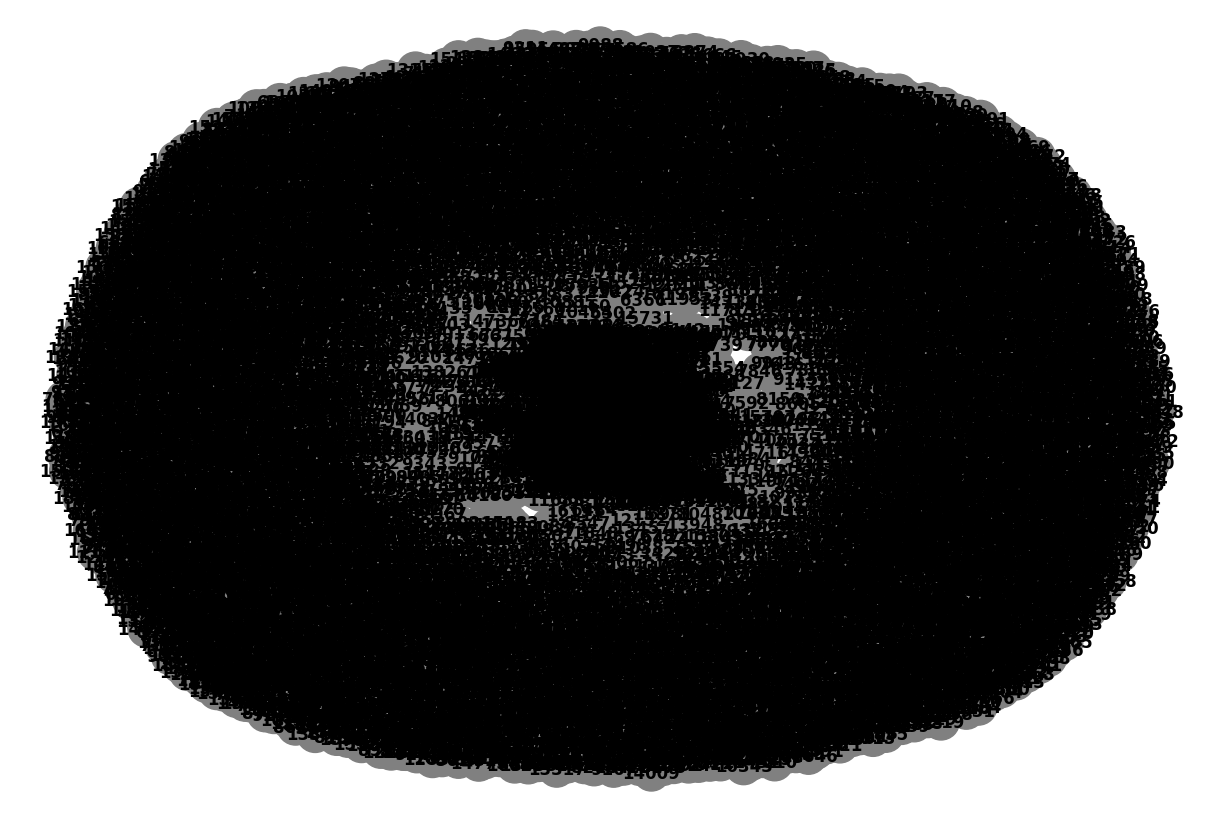

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Example color mapping for node tiers
tier_colours = {'tier0': 'red', 'tier1': 'blue', 'tier2': 'green'}

# Positioning for consistent node placement
pos = nx.spring_layout(G, seed=42)

# Build color map for nodes
node_colours = [tier_colours.get(G.nodes[n].get('tier', None), 'grey') for n in G.nodes()]

# Plot the base graph
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color=node_colours, node_size=700, font_weight='bold', edge_color='#cccccc')

# Function to generate a random colour for each path
def random_colour():
    return [random.random() for _ in range(3)]

# Plot each path in df_filtered_paths
for path in df_filtered_paths:
    # Get edges for this path
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(
        G, pos,
        edgelist=path_edges,
        width=3,
        edge_color=[random_colour()],
        alpha=0.9
    )

plt.title("Attack Graph with All Filtered Paths Highlighted")
plt.show()

In [ ]:

# prompt: using min_weight_row plot the attack graph using networkx

import matplotlib.pyplot as plt

# Create a graph for the attack path
attack_graph = nx.DiGraph()

# Add nodes from the min_weight_row path
path_nodes = df_filtered_paths['path']
for node_id in path_nodes:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the min_weight_row path
for i in range(len(path_nodes) - 1):
    start_node = path_nodes[i]
    end_node = path_nodes[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
pos = nx.spring_layout(attack_graph)  # You can choose a different layout
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally
plt.figure(figsize=(12, 8))
nx.draw(attack_graph, pos, with_labels=False, node_size=700, node_color='skyblue', font_size=10, arrowsize=20)

# Add node labels
node_labels = nx.get_node_attributes(attack_graph, 'label')
nx.draw_networkx_labels(attack_graph, pos, labels=node_labels, font_size=10)

# Add edge labels
edge_labels = nx.get_edge_attributes(attack_graph, 'label')
nx.draw_networkx_edge_labels(attack_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title(f"Attack Graph (Min Weight Path from {min_weight_row['source']} to {min_weight_row['target']})")
plt.show()

ValueError: ('Lengths must match to compare', (10076,), (2,))

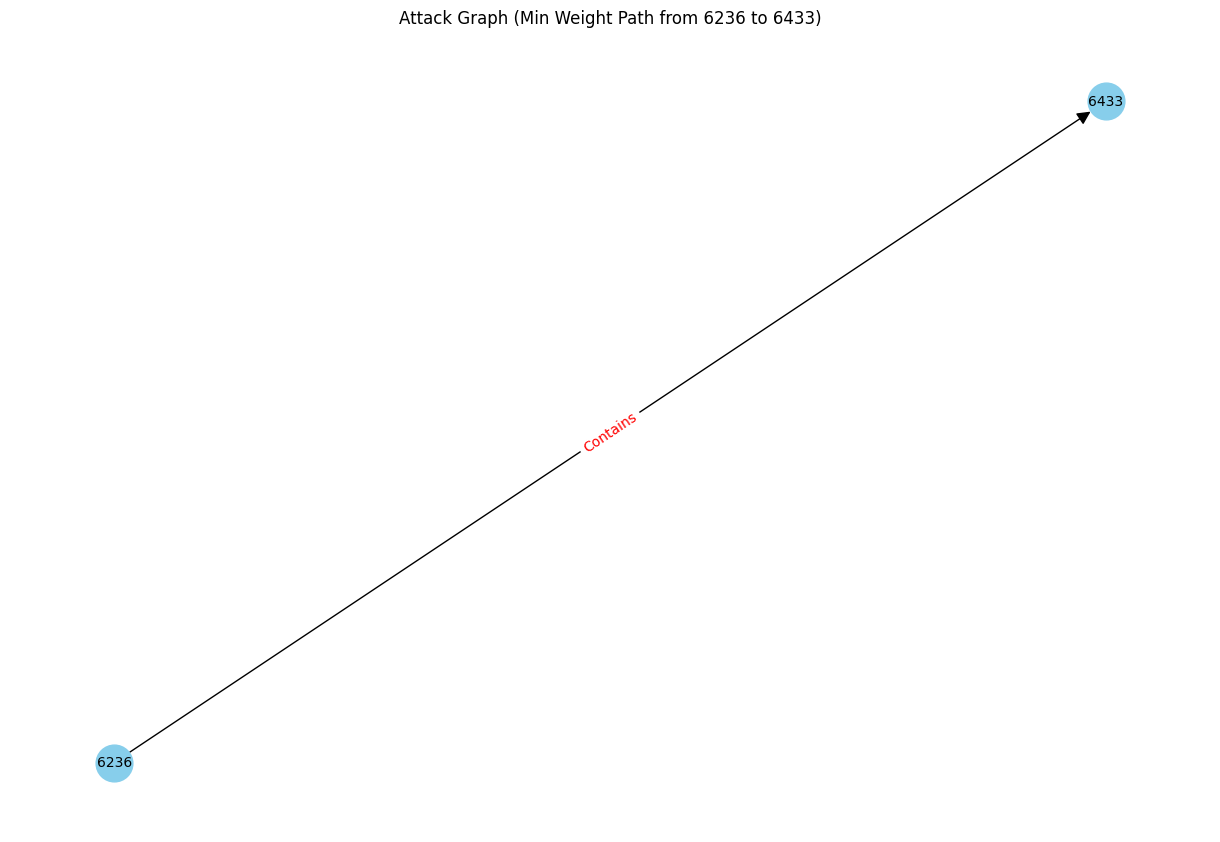

In [ ]:
# prompt: using min_weight_row plot the attack graph using networkx

import matplotlib.pyplot as plt

# Create a graph for the attack path
attack_graph = nx.DiGraph()

# Add nodes from the min_weight_row path
path_nodes = min_weight_row['path']
for node_id in path_nodes:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the min_weight_row path
for i in range(len(path_nodes) - 1):
    start_node = path_nodes[i]
    end_node = path_nodes[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
pos = nx.spring_layout(attack_graph)  # You can choose a different layout
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally
plt.figure(figsize=(12, 8))
nx.draw(attack_graph, pos, with_labels=False, node_size=700, node_color='skyblue', font_size=10, arrowsize=20)

# Add node labels
node_labels = nx.get_node_attributes(attack_graph, 'label')
nx.draw_networkx_labels(attack_graph, pos, labels=node_labels, font_size=10)

# Add edge labels
edge_labels = nx.get_edge_attributes(attack_graph, 'label')
nx.draw_networkx_edge_labels(attack_graph, pos, edge_labels=edge_labels, font_color='red')

plt.title(f"Attack Graph (Min Weight Path from {min_weight_row['source']} to {min_weight_row['target']})")
plt.show()

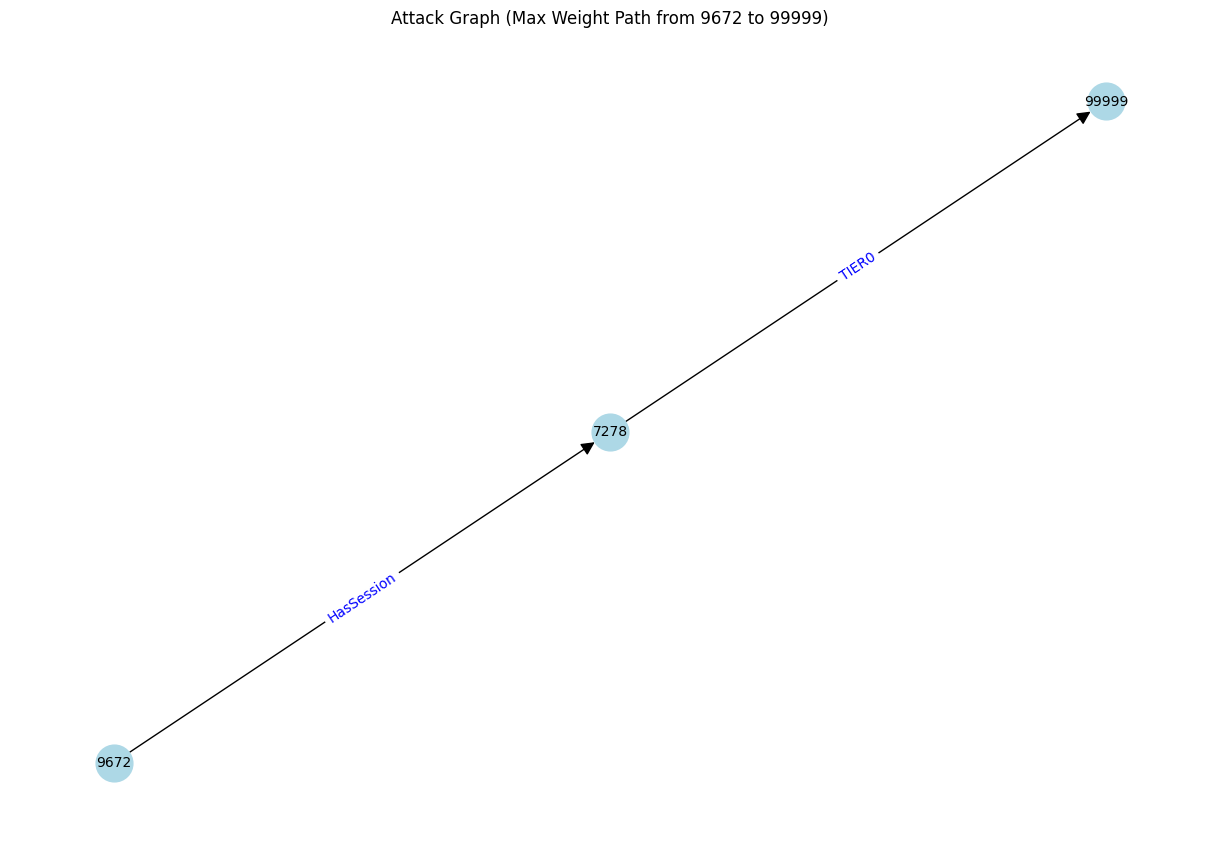

In [ ]:
# prompt: using max_weight_row plot the attack graph using networkx starting at the bottom left and ending up top right

import matplotlib.pyplot as plt
# Create a graph for the attack path using the max_weight_row
attack_graph_max = nx.DiGraph()

# Add nodes from the max_weight_row path
path_nodes_max = max_weight_row['path']
for node_id in path_nodes_max:
    # Find the node properties from the original 'nodes' DataFrame
    node_info = nodes[nodes['id'] == node_id].iloc[0]
    attack_graph_max.add_node(node_id, label=node_info.get('name', str(node_id)), weight=node_info.get('weight', 1))

# Add edges from the max_weight_row path
for i in range(len(path_nodes_max) - 1):
    start_node = path_nodes_max[i]
    end_node = path_nodes_max[i+1]
    # Find the edge properties from the original 'edges' DataFrame
    edge_info = edges[(edges['start'] == start_node) & (edges['end'] == end_node)].iloc[0]
    attack_graph_max.add_edge(start_node, end_node, label=edge_info.get('label', 'Unknown'), weight=edge_info.get('weight', 1))

# Draw the graph
# Use a different layout that allows positioning
pos_max = {}
num_nodes = len(path_nodes_max)
# Simple linear positioning from bottom left to top right
for i, node_id in enumerate(path_nodes_max):
    pos_max[node_id] = (i, i) # Positions nodes diagonally

plt.figure(figsize=(12, 8))
nx.draw(attack_graph_max, pos_max, with_labels=False, node_size=700, node_color='lightblue', font_size=10, arrowsize=20)

# Add node labels
node_labels_max = nx.get_node_attributes(attack_graph_max, 'label')
nx.draw_networkx_labels(attack_graph_max, pos_max, labels=node_labels_max, font_size=10)

# Add edge labels
edge_labels_max = nx.get_edge_attributes(attack_graph_max, 'label')
nx.draw_networkx_edge_labels(attack_graph_max, pos_max, edge_labels=edge_labels_max, font_color='blue')

plt.title(f"Attack Graph (Max Weight Path from {max_weight_row['source']} to {max_weight_row['target']})")
plt.show()

In [ ]:
/1


<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
/tmp/ipython-input-94-691856829.py:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
  1()


TypeError: 'int' object is not callable

In [ ]:
df_shortest_paths_with_weight

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
min_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].min().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_min = pd.merge(df_shortest_paths_with_weight, min_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Minimum Weight: {row['total_weight']}, Path: {row['path']}")


In [ ]:
# prompt: for each source find MAXIMUM weight and target. only save the max results in result_max

import pandas as pd
# Group by source and find the maximum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the maximum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
for index, row in result_max.iterrows():
  print(f"Source: {row['source']}, Target: {row['target']}, Maximum Weight: {row['total_weight']}, Path: {row['path']}")

In [ ]:
# prompt: for each source find minimum weight and target. if weight is the same print out all instances

import pandas as pd
# Group by source and find the minimum weight
max_weights = df_shortest_paths_with_weight.groupby('source')['total_weight'].max().reset_index()

# Merge with the original DataFrame to get rows with the minimum weight
result_max = pd.merge(df_shortest_paths_with_weight, max_weights, on=['source', 'total_weight'])

# Print the results
# for index, row in result.iterrows():
#   print(f"Source: {row['source']}, Target: {row['target']}, Max Weight: {row['total_weight']}, Path: {row['path']}")
# df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# df_shortest_paths_with_weight

In [ ]:
# prompt: for each source IN df_shortest_paths_with_weight find maximum weight and target AND PATH. if weight is the same print out all instances

# Iterate through each unique source node
for source_node in df_shortest_paths_with_weight['source'].unique():
    # Filter the DataFrame for the current source node
    source_df = df_shortest_paths_with_weight[df_shortest_paths_with_weight['source'] == source_node].copy()

    # Find the maximum weight for this source
    max_weight_for_source = source_df['total_weight'].max()

    # Filter for rows with the maximum weight for this source
    max_weight_paths = source_df[source_df['total_weight'] == max_weight_for_source]

    # Print the results for the current source
    print(f"\nSource: {source_node}")
    print(f"Maximum Weight for this source: {max_weight_for_source}")
    print("Paths with maximum weight:")
    for index, row in max_weight_paths.iterrows():
        print(f"  Target: {row['target']}, Path: {row['path']}")

In [108]:
shortest_paths_with_weight

[{'source': 15, 'target': 301, 'path': [15, 301], 'total_weight': np.int64(2)},
 {'source': 15, 'target': 318, 'path': [15, 318], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 331, 'path': [26, 331], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 341, 'path': [26, 341], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 357, 'path': [26, 357], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 405, 'path': [26, 405], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 444, 'path': [26, 444], 'total_weight': np.int64(2)},
 {'source': 26, 'target': 448, 'path': [26, 448], 'total_weight': np.int64(2)},
 {'source': 27, 'target': 392, 'path': [27, 392], 'total_weight': np.int64(2)},
 {'source': 29, 'target': 481, 'path': [29, 481], 'total_weight': np.int64(2)},
 {'source': 486,
  'target': 444,
  'path': [486, 444],
  'total_weight': np.int64(9)},
 {'source': 490,
  'target': 331,
  'path': [490, 331],
  'total_weight': np.int64(9)},
 {'source': 494,
  'targ

In [ ]:
result_min

In [ ]:
result_max

In [ ]:
# prompt: show me where source appears the most within the results_max dataframe. is ther one source that appears most

source_counts = result_max['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts)

most_frequent_source = source_counts.index[0]
most_frequent_count = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [ ]:
source_counts_min = result_min['source'].value_counts()

print("Count of each source in result_max:")
print(source_counts_min)

most_frequent_source_min = source_counts.index[0]
most_frequent_count_min = source_counts.iloc[0]

print(f"\nThe source that appears most frequently is: {most_frequent_source} with a count of {most_frequent_count}")

if most_frequent_count_min > 1:
  print("Yes, there is one source that appears most.")
else:
  print("No single source appears most frequently (or all sources appear only once).")

In [60]:
# prompt: convert result into a DataFrame

import pandas as pd
df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
df_shortest_paths_with_weight

NameError: name 'shortest_paths_with_weight' is not defined

In [ ]:
print(edges[edges['end'] == 301])

In [ ]:
shortest_paths_with_weight

In [ ]:
# prompt: for each node in shortest_paths_with_weight, find the minimum total_weight and the maxium total_weight, save it to a DataFrame

import pandas as pd
# Initialize a dictionary to store min and max weights for each target node
target_node_weights = {}

# Iterate through the shortest paths
for path_info in shortest_paths_with_weight:
    target_node = path_info['target']
    total_weight = path_info['total_weight']

    if target_node not in target_node_weights:
        target_node_weights[target_node] = {'min_weight': float('inf'), 'max_weight': float('-inf')}

    # Update min and max weights
    target_node_weights[target_node]['min_weight'] = min(target_node_weights[target_node]['min_weight'], total_weight)
    target_node_weights[target_node]['max_weight'] = max(target_node_weights[target_node]['max_weight'], total_weight)

# Convert the dictionary to a DataFrame
min_max_weights_df = pd.DataFrame.from_dict(target_node_weights, orient='index')
min_max_weights_df.index.name = 'target_node'
min_max_weights_df = min_max_weights_df.reset_index()

# Display the resulting DataFrame
print("\nMin and Max Total Weights for Each Target Node:")
min_max_weights_df

In [ ]:
# prompt: for each record in "for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path

# Find the path with the smallest total weight
min_weight_path_info = min(shortest_paths_with_weight, key=lambda item: item['total_weight'])

# Find the path with the largest total weight
max_weight_path_info = max(shortest_paths_with_weight, key=lambda item: item['total_weight'])

print("\nPath with the Smallest Combined Weight:")
print(f"Source: {min_weight_path_info['source']}, Target: {min_weight_path_info['target']}, Total Weight: {min_weight_path_info['total_weight']}, Path: {min_weight_path_info['path']}")

print("\nPath with the Largest Combined Weight:")
print(f"Source: {max_weight_path_info['source']}, Target: {max_weight_path_info['target']}, Total Weight: {max_weight_path_info['total_weight']}, Path: {max_weight_path_info['path']}")

In [ ]:
# prompt: for each record in "shortest_paths_filtered" add up the weights and find the smallest and largest combined weights and the path for the largest weight

# Function to calculate the total weight of a path
# def calculate_path_weight(graph, path):
#     total_weight = 0
#     for i in range(len(path) - 1):
#         # Add node weight
#         total_weight += graph.nodes[path[i]].get('weight', 0)
#         # Add edge weight
#         total_weight += graph[path[i]][path[i+1]].get('weight', 0)
#     # Add the weight of the last node in the path
#     if path:
#         total_weight += graph.nodes[path[-1]].get('weight', 0)
#     return total_weight

# all_path_weights = {}

# # Iterate through each source and its paths in shortest_paths_filtered
# for source, paths_from_source in shortest_paths_list.items():
#     all_path_weights[source] = {}
#     # Iterate through each target and its path
#     for target, path in paths_from_source.items():
#         # Calculate the weight of the path using the original graph G
#         weight = calculate_path_weight(G, path)
#         all_path_weights[source][target] = weight

# # Find the smallest and largest combined weights
# min_weight = float('inf')
# max_weight = float('-inf')
# largest_weight_path = None
# largest_weight_source = None
# largest_weight_target = None

# for source, paths_from_source in all_path_weights.items():
#     for target, weight in paths_from_source.items():
#         if weight < min_weight:
#             min_weight_source = source
#             min_weight_target = target
#             min_weight_path = shortest_paths_filtered[source][target]
#             min_weight = weight
#         if weight > max_weight:
#             max_weight = weight
#             largest_weight_source = source
#             largest_weight_target = target
#             largest_weight_path = shortest_paths_filtered[source][target]

# print(f"Smallest combined weight: {min_weight}")
# print(f"Path for the smallest weight: {min_weight_path}")
# print(f"Source for the smallest weight path: {min_weight_source}")
# print(f"Target for the smallest weight path: {min_weight_target}")
# print(f"Largest combined weight: {max_weight}")
# print(f"Path for the largest weight: {largest_weight_path}")
# print(f"Source for the largest weight path: {largest_weight_source}")
# print(f"Target for the largest weight path: {largest_weight_target}")

In [ ]:

print(nodes[nodes['id'] == 111])
print(nodes[nodes['id'] == 8])
print(nodes[nodes['id'] == 26])
#print(nodes[nodes['id'] == 444])
#print(nodes[nodes['id'] == 331])
#print(nodes[nodes['id'] == 208])

In [ ]:
selected_nodes

In [ ]:
selected_nodes

In [ ]:
pd.set_option("display.max_rows", None, "display.max_columns", None)
shortest_paths

In [ ]:
shortest_paths_filtered

In [ ]:
# prompt: can you display the combined weight from the shortest_paths and display the path with the max weight

# Function to calculate the total weight of a path
def calculate_path_weight(graph, path):
    total_weight = 0
    # Add the weight of the starting node
    if path:
        total_weight += graph.nodes[path[0]].get('weight', 0) # Get node weight
    # Add the weight of the edges and the weights of subsequent nodes
    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # Add edge weight
        total_weight += graph.edges[u, v].get('weight', 0) # Get edge weight
        # Add weight of the next node
        total_weight += graph.nodes[v].get('weight', 0) # Get node weight
    return total_weight

max_weight = -1
max_path = None

# Iterate through the filtered shortest paths and calculate total weights
for source, paths in shortest_paths_filtered.items():
    for target, path in paths.items():
        current_weight = calculate_path_weight(G, path)
#        print(f"Path from {source} to {target}: {path}, Combined Weight: {current_weight}")
        if current_weight > max_weight:
            max_weight = current_weight
            max_path = path

print(f"\nPath with the maximum combined weight: {max_path}")
print(f"Maximum combined weight: {max_weight}")

In [ ]:
max_path
max_path = pd.DataFrame(max_path)
max_path.head()


In [ ]:
rename = {0: 'id'}
max_path = max_path.rename(columns=rename)
max_path

In [ ]:
# prompt: get label from nodes where id=max_path['id']

# Assuming max_path is a DataFrame with an 'id' column representing the node IDs in the max path
# and nodes is a DataFrame with 'id' and 'properties' columns.

# Get the list of node IDs from the max_path DataFrame
max_path_node_ids = max_path['id'].tolist()

# Filter the nodes DataFrame to get only the nodes that are in the max_path
nodes_in_max_path = nodes[nodes['id'].isin(max_path_node_ids)].copy()

# Now, extract the 'name' property from the 'properties' column for these nodes
# Use .loc to avoid SettingWithCopyWarning
# We use a lambda function with .apply to safely access nested dictionary keys.
max_path_node_labels = nodes_in_max_path.loc[:, 'properties'].apply(lambda x: x.get('name', ''))

print("Labels of nodes in the max path:")
print(max_path_node_labels.tolist())


In [ ]:
max_path

ignore from here


In [ ]:
vertices = nodes['id'].tolist()
vertices


In [ ]:
adj_list=adj.values.tolist()
len(adj_list)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def createAdjacencyMatrix(vertices,edges):
  noofvertices=len(vertices)
  adjM=[]
  while(len(adjM)<noofvertices):
    temp=[]
    for i in range(noofvertices):
      temp.append(0)
    adjM.append(temp)
  for edge in edges:
    i=edge[0]
    j=edge[1]
    if i>=noofvertices or j>=noofvertices or i<0 or j<0:
      print(f"Not a Proper Input in Edge {i},{j}")
    else:
      adjM[i][j]=1
      adjM[j][i]=1
#  G=nx.Graph()
#  G.add_edges_from(edges)
#  nx.draw_networkx(G)
#  plt.show()
  return adjM
vertices = vertices
edges = adj_list
adjM=createAdjacencyMatrix(vertices,edges)


In [ ]:
#adjM.shape
import numpy as np
len(adjM)
arr = np.array(adjM)

newarr = arr.reshape(10075, 10075)

print(newarr)

In [ ]:
def create_adjacency_matrix(V, edges):
    # Initialize an empty V x V matrix with all zeros
    matrix = [[0] * V for _ in range(V)]

    # Populate the matrix based on the edges
    for edge in edges:
        u, v = edge
        matrix[u][v] = 1
#       matrix[v][u] = 1  # Undirected graph

    return matrix
V1 = len(adj)
edges1 = adj[['start', 'end']].values.tolist()
adj_matrix1 = create_adjacency_matrix(V1, edges1)
for row in adj_matrix1:
    print(row)
print()

In [ ]:
type(adj)

In [ ]:
import pandas as pd

# Initialize an empty DataFrame to store selected records
selected_records = pd.DataFrame(columns=filtered_nodes_regex.columns)

# Iterate through each row of the filtered_nodes_regex DataFrame
for index, row in filtered_nodes_regex.iterrows():
    properties = row['properties']

    # Check if 'properties' is a dictionary and contains 'highvalue' and if 'highvalue' is True
    if isinstance(properties, dict) and 'highvalue' in properties and properties['highvalue'] == True:
        # Append the entire row to the selected_records DataFrame
        selected_records = pd.concat([selected_records, pd.DataFrame([row])], ignore_index=True)

# Display the selected_records DataFrame
print("Selected records where 'highvalue' is True:")
display(selected_records)

Selected records where 'highvalue' is True:


,id,properties,type,l1,l2,l3,weight


In [ ]:
# Create a new node ID based on the length of lastnode
new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

NameError: name 'lastnode' is not defined